In [ ]:
!pip install langgraph langsmith

In [ ]:
!pip install -q langchain langchain_groq langchain_community

In [ ]:
# to access api key
from google.colab import userdata
groq_api_key = userdata.get('groq_api_key')

In [ ]:
langsmith_api_key = userdata.get('langsmith_api_key')

In [ ]:
import os
os.environ["LANGCHAIN_API_KEY"]=langsmith_api_key # Connects your code to LangSmith, Used to track your LLM calls
os.environ["LANGCHAIN_TRACING_V2"]= "true" # Turns ON tracing (logging of every step), You can see: prompts,responses,chain steps,errors
os.environ["LANGCHAIN_PROJECT"]="CourseLangGraph" # Groups your logs under a project name

In [ ]:
from langchain_groq import ChatGroq
llm = ChatGroq(groq_api_key=groq_api_key,model_name="llama-3.1-8b-instant")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7e8b05c03d40>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7e8b05cc9790>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [ ]:
# Start building ChatBot using LangGraph
# Used to add extra metadata to types, Helps LangGraph understand how to treat data
from typing import Annotated
# Used to create a structured dictionary (like schema)
from typing_extensions import TypedDict
# StateGraph → used to build chatbot workflow, START → where execution begins , END → where execution stops
from langgraph.graph import StateGraph, START, END
# Used to append messages to chat history automatically
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
  # messages have the type "list", and "add_messages" function
  # in the annotation defines how this state key should be updated
  # in this case it appends messages to the list rather overwrite them
    messages:Annotated[list,add_messages]

In [ ]:
# graph builder
graph_builder = StateGraph(State)
graph_builder

In [ ]:
# chatbot
def chatbot(state:State):
  return {"messages":llm.invoke(state["messages"])}

In [ ]:
# add chatbot node to the graph_builder
graph_builder.add_node("chatbot",chatbot)
graph_builder

In [ ]:
# add node edges
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

In [ ]:
# compile
graph = graph_builder.compile()

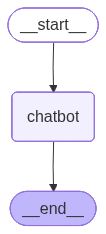

In [ ]:
# display graph
from IPython.display import Image,display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
  print(e)

In [ ]:
while True:
  user_input = input("User :")
  if user_input.lower() in ["quit","exit","q"]:
    print("quitting")
    break
  for event in graph.stream({"messages":("user",user_input)}):
    print(event.values())
    for value in event.values():
      print(value["messages"])
      print("Assistant: ",value["messages"].content)

User :hi
dict_values([{'messages': AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.006049878, 'completion_tokens_details': None, 'prompt_time': 0.002421125, 'prompt_tokens_details': None, 'queue_time': 0.005514046, 'total_time': 0.008471003}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d317489708', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d68c6-cbf6-71a0-98f1-992cbc1200e0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})}])
content='How can I assist you today?' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.006049878, 'completion_tokens_details': None, 'prompt_time': 0.002421125, 'prompt_toke